### Usage-Based Station Clustering Analysis

* **Objective:** Segment bike share stations based on rider behavior to identify distinct operational roles across the network.
* **Methodology:** Engineered usage metrics from the raw trip data and applied the K-Means clustering algorithm to group stations with mathematically similar patterns.
* **Key Features Evaluated:**
  * **Morning Commute Signal:** Proportion of trips occurring during the morning rush (7 AM - 9 AM).
  * **Leisure Signal:** Proportion of trips occurring on weekends.
  * **Ride Characteristic:** Average duration of trips originating from the station.
* **Visualization:** The chart below reflects the resulting clusters of stations, plotted on the axes of Proportion of Weekend Trips vs. Proportion of Morning Rush Trips. 

![Station Clusters](Station_Clusters.jpg)

* **Key Findings:**
  * **Cluster 0 (Commuter Hubs):** High morning rush usage, indicating stations used primarily for daily work commutes.
  * **Cluster 1 (Standard/Mixed):** Lower, steady traffic spread evenly throughout the week.
  * **Cluster 2 (Leisure Spots):** High weekend usage with minimal morning commutes, suggesting locations near recreational areas.

In [58]:
import pandas as pd
import os
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [59]:
dataset_handle = "kalacheva/london-bike-share-usage-dataset"
path = kagglehub.dataset_download(dataset_handle)

In [60]:
files = os.listdir(path)

In [61]:
# Create the full path to the specific file
csv_path = os.path.join(path, "LondonBikeJourneyAug2023.csv")

# Load the data
df_bikes = pd.read_csv(csv_path)

# Display the first 5 rows
df_bikes.head()

,Number,Start date,Start station number,Start station,End date,End station number,End station,Bike number,Bike model,Total duration,Total duration (ms)
0,132825189,8/1/2023 0:00,1190,"Kennington Lane Rail Bridge, Vauxhall",8/1/2023 0:17,1059,"Albert Embankment, Vauxhall",23715,CLASSIC,16m 46s,1006663
1,132825190,8/1/2023 0:00,1190,"Kennington Lane Rail Bridge, Vauxhall",8/1/2023 0:17,1059,"Albert Embankment, Vauxhall",41267,CLASSIC,16m 47s,1007128
2,132825191,8/1/2023 0:00,983,"Euston Road, Euston",8/1/2023 0:11,3500,"Baldwin Street, St. Luke's",53180,CLASSIC,11m 6s,666395
3,132825192,8/1/2023 0:01,3479,"Old Brompton Road, South Kensington",8/1/2023 0:12,1140,"Grosvenor Road, Pimlico",53431,CLASSIC,11m 53s,713059
4,132825193,8/1/2023 0:01,1219,"Lower Marsh, Waterloo",8/1/2023 0:17,200056,"Vauxhall Walk, Vauxhall",54758,CLASSIC,16m 3s,963786


In [62]:
# Extract day of week from Start date and create new column
df_bikes['Start date'] = pd.to_datetime(df_bikes['Start date'])
df_bikes['Day of Week'] = df_bikes['Start date'].dt.day_name()

In [63]:
# Extract hour from 'Start date' and create new column
df_bikes['Hour'] = df_bikes['Start date'].dt.hour

In [64]:
# 1. Create usage flags in the main dataframe
df_bikes['Is Weekend'] = df_bikes['Day of Week'].isin(['Saturday', 'Sunday']).astype(int)
df_bikes['Is Morning Rush'] = df_bikes['Hour'].between(7, 9).astype(int)

In [65]:
# Check if 'Hour' column matches the hour extracted from 'Start date'
hour_from_start_date = df_bikes['Start date'].dt.hour
comparison = df_bikes['Hour'] == hour_from_start_date

# Display mismatches, if any
mismatches = df_bikes.loc[~comparison, ['Start date', 'Hour']]
print(f"Number of mismatches: {len(mismatches)}")
mismatches.head()

Number of mismatches: 0


,Start date,Hour


In [66]:
print(df_bikes.dtypes)

Number                           int64
Start date              datetime64[ns]
Start station number             int64
Start station                   object
End date                        object
End station number               int64
End station                     object
Bike number                      int64
Bike model                      object
Total duration                  object
Total duration (ms)              int64
Day of Week                     object
Hour                             int32
Is Weekend                       int64
Is Morning Rush                  int64
dtype: object


In [67]:
# 2. Group by station to calculate our new features
station_stats = df_bikes.groupby('Start station').agg(
    Total_Trips=('Start station', 'count'),
    Avg_Duration=('Total duration (ms)', 'mean'),
    Pct_Weekend=('Is Weekend', 'mean'),
    Pct_Morning=('Is Morning Rush', 'mean')
).reset_index()

In [68]:
# Optional: Filter out obscure stations with very few trips to reduce noise
station_stats = station_stats[station_stats['Total_Trips'] > 50]

In [69]:
# 3. Scale the features
features = ['Avg_Duration', 'Pct_Weekend', 'Pct_Morning']
scaler = StandardScaler()
scaled_features = scaler.fit_transform(station_stats[features])

In [70]:
# 4. Apply K-Means clustering (asking for 3 clusters)
kmeans = KMeans(n_clusters=3, random_state=42)
station_stats['Cluster'] = kmeans.fit_predict(scaled_features)

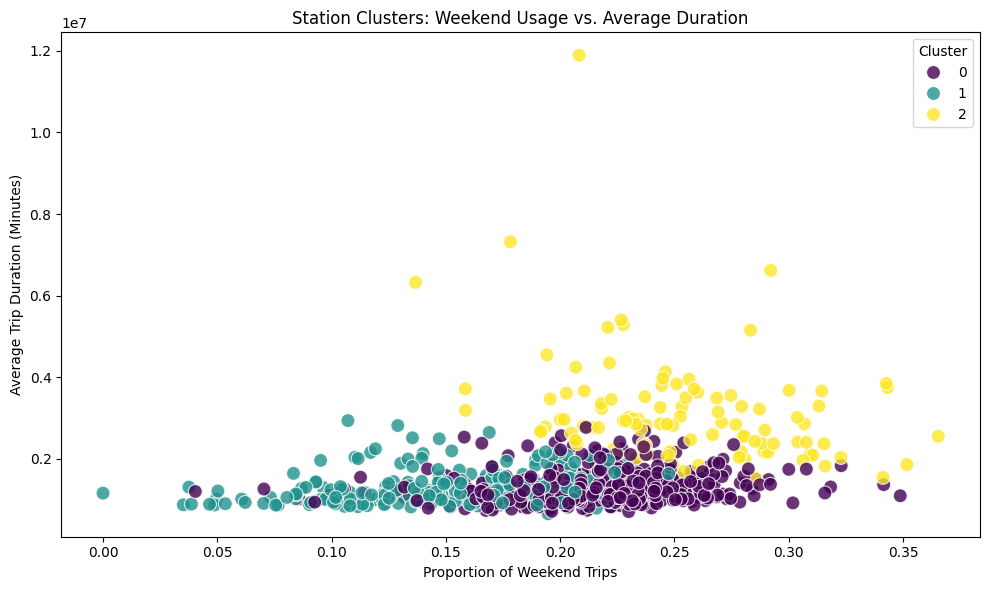

In [71]:
# 5. Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=station_stats, 
    x='Pct_Weekend', 
    y='Avg_Duration', 
    hue='Cluster', 
    palette='viridis', 
    s=100, 
    alpha=0.8
)
plt.title('Station Clusters: Weekend Usage vs. Average Duration')
plt.xlabel('Proportion of Weekend Trips')
plt.ylabel('Average Trip Duration (Minutes)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

In [72]:
# Group the station data by the newly assigned clusters
cluster_summary = station_stats.groupby('Cluster').agg(
    Number_of_Stations=('Start station', 'count'),
    Total_Trips_in_Cluster=('Total_Trips', 'sum'),
    Average_Duration_mins=('Avg_Duration', 'mean'),
    Average_Pct_Weekend=('Pct_Weekend', 'mean'),
    Average_Pct_Morning=('Pct_Morning', 'mean')
).reset_index()

# Print the summary table
print(cluster_summary)

   Cluster  Number_of_Stations  Total_Trips_in_Cluster  Average_Duration_mins  \
0        0                 458                  410185           1.301228e+06   
1        1                 237                  250837           1.334584e+06   
2        2                 105                  115505           3.128422e+06   

   Average_Pct_Weekend  Average_Pct_Morning  
0             0.218392             0.258415  
1             0.152114             0.109344  
2             0.253366             0.150854  


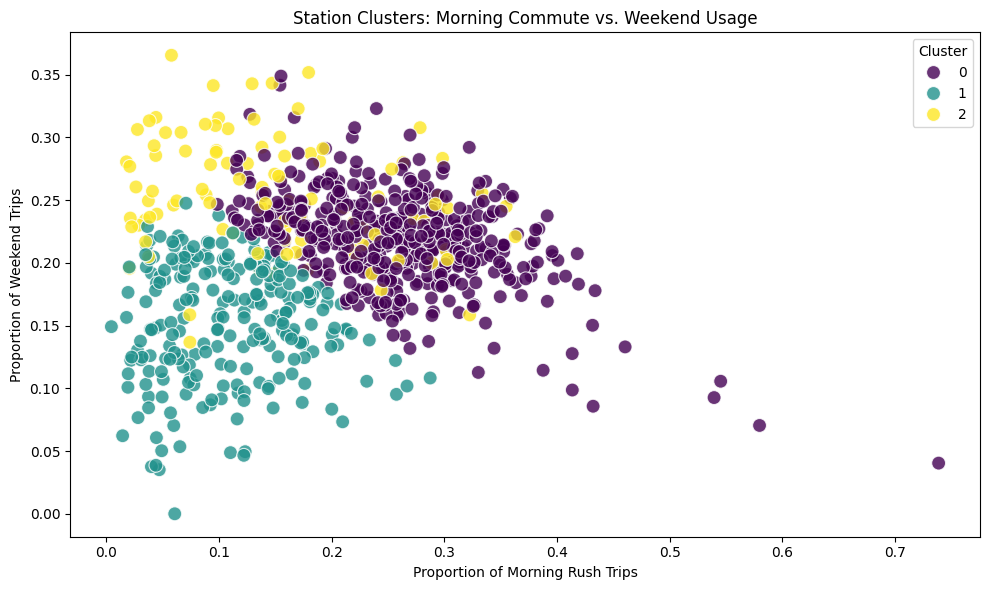

In [73]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=station_stats, 
    x='Pct_Morning', 
    y='Pct_Weekend', 
    hue='Cluster', 
    palette='viridis', 
    s=100, 
    alpha=0.8
)
plt.title('Station Clusters: Morning Commute vs. Weekend Usage')
plt.xlabel('Proportion of Morning Rush Trips')
plt.ylabel('Proportion of Weekend Trips')
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig('Station_Clusters.jpg', bbox_inches='tight')
plt.show()

In [74]:
# Convert Cluster to a string so Plotly treats it as a distinct category (not a continuous number)
station_stats['Cluster_Category'] = station_stats['Cluster'].astype(str)

# Create the interactive 3D scatter plot
fig = px.scatter_3d(
    station_stats, 
    x='Pct_Morning', 
    y='Pct_Weekend', 
    z='Avg_Duration',
    color='Cluster_Category',
    title='Interactive 3D View: Station Usage Clusters',
    labels={
        'Pct_Morning': 'Morning Rush',
        'Pct_Weekend': 'Weekend %',
        'Avg_Duration': 'Average Duration (mins)'
    },
    opacity=0.8
)

# Display the plot
fig.show()